<a href="https://colab.research.google.com/github/MohammedTaha-751/FUTURE_ML_1/blob/main/FUTURE_ML_1_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

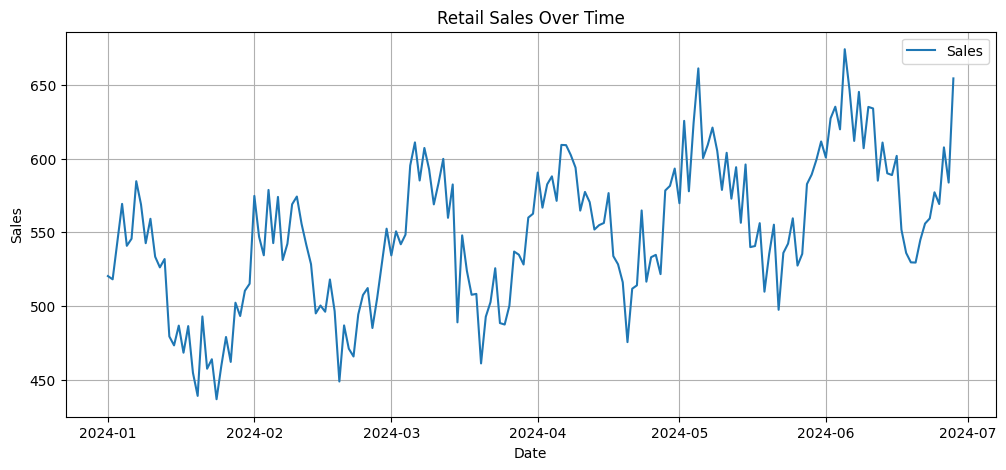

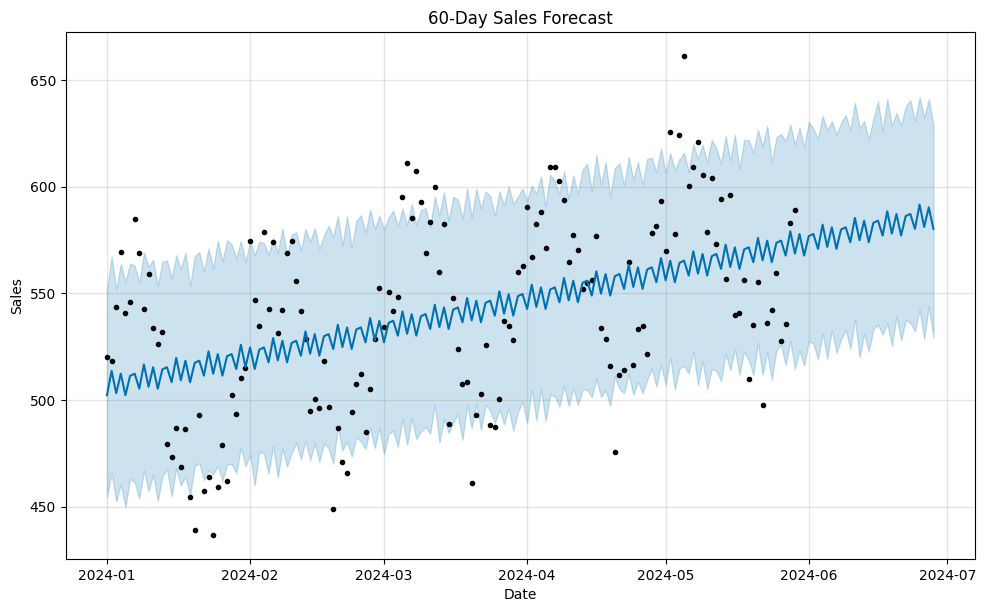

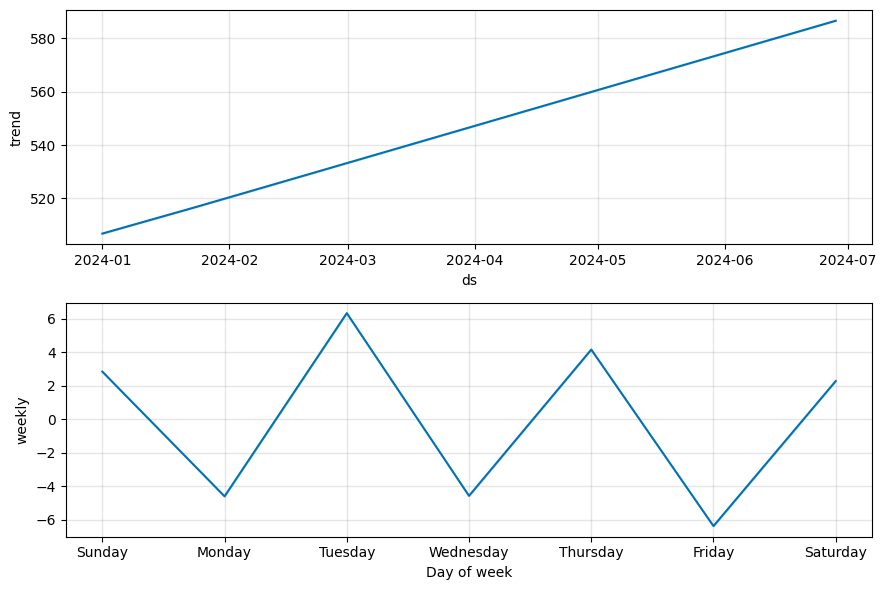

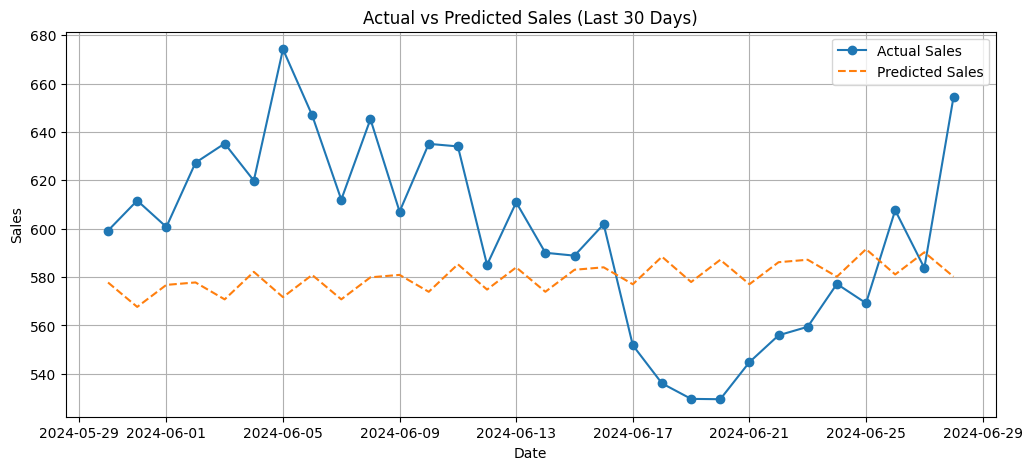

📊 Mean Absolute Error (Last 30 Days): 37.85


In [9]:
# 📌 Task 1: AI-Powered Sales Forecasting Dashboard - Future Interns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Step 1: Generate synthetic daily sales data (6 months)
np.random.seed(42)
date_range = pd.date_range(start='2024-01-01', periods=180, freq='D')
trend = np.linspace(500, 600, len(date_range))  # linear upward trend
seasonality = 50 * np.sin(2 * np.pi * date_range.dayofyear / 30)  # monthly pattern
noise = np.random.normal(0, 20, len(date_range))  # random variation
sales = trend + seasonality + noise

df = pd.DataFrame({'ds': date_range, 'y': sales})

# Step 2: Visualize the raw sales data
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], label='Sales')
plt.title('Retail Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend()
plt.show()

# Step 3: Train/Test Split (last 30 days for testing)
train = df.iloc[:-30]
test = df.iloc[-30:]

# Step 4: Train Prophet model on training data
model = Prophet()
model.fit(train)

# Step 5: Forecast for full timeline (30 days into future)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Step 6: Plot the full forecast
model.plot(forecast)
plt.title("60-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# Step 7: Trend & seasonality components
model.plot_components(forecast)
plt.show()

# Step 8: Evaluate forecast against actual test data
forecast_df = forecast[['ds', 'yhat']].set_index('ds')
actual_df = test.set_index('ds')
comparison_df = forecast_df.join(actual_df).dropna()

# Step 9: Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(comparison_df.index, comparison_df['y'], label='Actual Sales', marker='o')
plt.plot(comparison_df.index, comparison_df['yhat'], label='Predicted Sales', linestyle='--')
plt.title("Actual vs Predicted Sales (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Print MAE score
mae = mean_absolute_error(comparison_df['y'], comparison_df['yhat'])
print(f"📊 Mean Absolute Error (Last 30 Days): {mae:.2f}")
